#Question_2

In [ ]:
# 2 Solution a)

In [28]:
def decimal_to_binary(decimal): 
    """
    Convert a decimal number to its binary equivalent.
    """
    if decimal == 0:
        return "0"

    sign = "-" if decimal < 0 else ""
    decimal = abs(decimal)

    integer_part = int(decimal)
    fractional_part = decimal - integer_part
    binary = ""
    if integer_part == 0:
        binary = "0"
    else:
        while integer_part > 0:
            binary = str(integer_part % 2) + binary
            integer_part //= 2

    if fractional_part:
        binary += "."
        for _ in range(32):  # Limit digits for fractions with repeating binary expansions
            fractional_part *= 2
            bit = int(fractional_part)
            binary += str(bit)
            fractional_part -= bit
            if fractional_part == 0:
                break

    return sign + binary
n= float(input("Enter a decimal number: "))
print(n , "in binary is: ",decimal_to_binary(n))

9339339.0 in binary is:  100011101000000111001011


In [ ]:
# ques_2b


In [14]:
import math
def decimal_to_ieee(num):
    if num == 0:
        return "0" * 32  # Special case for zero

    sign_bit = '0' if num >= 0 else '1'       # represented as s
    num = abs(num)

    exponent = 0
    while num >= 2:
        num /= 2
        exponent += 1
    while num < 1:
        num *= 2
        exponent -= 1

    exponent += 1023  # Bias for double precision      #represented as e
    exponent_bits = f"{exponent:011b}"

    mantissa = ""                                          #represented as m 
    num -= 1  # Remove the leading 1 for normalized numbers
    for _ in range(52):
        num *= 2
        if num >= 1:
            mantissa += '1'
            num -= 1
        else:
            mantissa += '0'

    ieee754_binary = sign_bit + (" = s") , exponent_bits + (" = e") , mantissa + (" = m")
    return ieee754_binary
n= float(input("Enter a number to convert to IEEE double precision: "))
print(n,"in IEEE is:", decimal_to_ieee(n))


8.342349234823884e+17 in IEEE is: ('0 = s', '10000111010 = e', '0111001001111001100001111100011000101100100100101111 = m')


#qus_2c

In [6]:
def ieee_to_decimal(s, e, f):
    sign_bit = str(s)
    exponent_bits = str(e)
    fraction_bits = str(f)

    if sign_bit not in {"0", "1"}:
        raise ValueError("Sign bit must be 0 or 1")
    if not exponent_bits or any(bit not in "01" for bit in exponent_bits):
        raise ValueError("Exponent must contain only 0 and 1 bits")
    if any(bit not in "01" for bit in fraction_bits):
        raise ValueError("Fraction must contain only 0 and 1 bits")

    exponent = int(exponent_bits, 2)
    fraction = int(fraction_bits, 2) if fraction_bits else 0
    exponent_max = (1 << len(exponent_bits)) - 1
    bias = (1 << (len(exponent_bits) - 1)) - 1

    if exponent == exponent_max:
        if fraction == 0:
            return float("-inf") if sign_bit == "1" else float("inf")
        return float("nan")

    if exponent == 0:
        if fraction == 0:
            return -0.0 if sign_bit == "1" else 0.0
        value = (fraction / (2 ** len(fraction_bits))) * (2 ** (1 - bias))
    else:
        value = (1 + fraction / (2 ** len(fraction_bits))) * (
            2 ** (exponent - bias)
        )

    if sign_bit == "1":
        value = -value

    return value


s = input("Enter the sign bit (0 or 1): ")
e = input("Enter the exponent bits: ")
f = input("Enter the fraction bits: ")

print("The decimal equivalent is:", ieee_to_decimal(s, e, f))

The decimal equivalent is: 7.202517429043684e+67


In [ ]:
#2d

In [1]:
import math

def decimal_to_ieee_double(x):
    """
    Definition used in 2b:
    Converts a decimal value to IEEE-754 double-precision format:
    (s, e, m)
    s = sign bit
    e = 11-bit exponent
    m = 52-bit mantissa
    """
    # Handle special values
    if math.isnan(x):
        return ('0', '11111111111', '0000000000000000000000000000000000000000000000000001')
    if math.isinf(x):
        s = '0' if x > 0 else '1'
        return (s, '11111111111', '0000000000000000000000000000000000000000000000000000')

    if x == 0.0:
        return ('0', '00000000000', '0000000000000000000000000000000000000000000000000000')

    s = '0' if x > 0 else '1'
    y = abs(x)

    # Normalize y to [1,2)
    exponent = 0
    while y >= 2.0:
        y /= 2.0
        exponent += 1
    while y < 1.0:
        y *= 2.0
        exponent -= 1

    # Bias for double precision
    e = exponent + 1023
    exponent_bits = format(e, '011b')

    # Mantissa: remove leading 1 and keep 52 bits after decimal point
    fraction = y - 1.0
    mantissa = ""
    for _ in range(52):
        fraction *= 2.0
        if fraction >= 1.0:
            mantissa += '1'
            fraction -= 1.0
        else:
            mantissa += '0'

    return (s, exponent_bits, mantissa)


def ieee_to_decimal(s, e, m):
    """
    Definition used in 2c:
    Converts IEEE-754 double-precision bits (s, e, m) back to decimal.
    """
    s = str(s)
    e = str(e)
    m = str(m)

    if e == '11111111111':
        if m == '0' * 52:
            return float('inf') if s == '0' else float('-inf')
        return float('nan')

    exponent = int(e, 2)
    fraction = int(m, 2) / (2 ** 52)

    if exponent == 0:
        # Subnormal / zero-like case
        value = 0.0 + fraction * (2 ** (-1022))
        # For this question, normal and infinities are the main cases
    else:
        value = (1.0 + fraction) * (2 ** (exponent - 1023))

    if s == '1':
        value = -value

    return value


def verify_accuracy(values):
    for x in values:
        s, e, m = decimal_to_ieee_double(x)
        y = ieee_to_decimal(s, e, m)

        print(f"Original x = {x}")
        print(f"IEEE bits = s={s}, e={e}, m={m}")
        print(f"Recovered value = {y}")

        if math.isinf(x) or math.isinf(y):
            print("Accuracy check:", math.isinf(x) and math.isinf(y) and ((x > 0 and y > 0) or (x < 0 and y < 0)))
        elif math.isnan(x) or math.isnan(y):
            print("Accuracy check:", math.isnan(x) and math.isnan(y))
        else:
            print("Accuracy check:", x == y)
            print("Absolute error:", abs(x - y))
        print("-" * 70)

# Test values
numbers = [200.0, math.pi, float('inf'), float('-inf')]

verify_accuracy(numbers)

Original x = 200.0
IEEE bits = s=0, e=10000000110, m=1001000000000000000000000000000000000000000000000000
Recovered value = 200.0
Accuracy check: True
Absolute error: 0.0
----------------------------------------------------------------------
Original x = 3.141592653589793
IEEE bits = s=0, e=10000000000, m=1001001000011111101101010100010001000010110100011000
Recovered value = 3.141592653589793
Accuracy check: True
Absolute error: 0.0
----------------------------------------------------------------------
Original x = inf
IEEE bits = s=0, e=11111111111, m=0000000000000000000000000000000000000000000000000000
Recovered value = inf
Accuracy check: True
----------------------------------------------------------------------
Original x = -inf
IEEE bits = s=1, e=11111111111, m=0000000000000000000000000000000000000000000000000000
Recovered value = -inf
Accuracy check: True
----------------------------------------------------------------------


#Question_3

In [ ]:
#defining method 1 and 2

In [29]:
import numpy as np
import matplotlib.pyplot as plt

def method1(a, b, n):
    """
    Generates n equally spaced grid points between a and b using:
    g_i = a + i * h
    """
    h = (b - a) / (n - 1)
    # Using numpy array arithmetic for efficiency across large n
    i = np.arange(n, dtype=np.float64)
    gs = a + i * h
    
    # Enforce exact boundary values as specified in the assignment prompt
    gs[0] = a
    gs[-1] = b
    return gs


def method2(a, b, n):
    """
    Generates n equally spaced grid points between a and b using recurrence:
    g_i = g_{i-1} + h
    """
    h = (b - a) / (n - 1)
    gs = np.empty(n, dtype=np.float64)
    gs[0] = a
    for i in range(1, n):
        gs[i] = gs[i - 1] + h
        
    # Enforce exact boundary values as specified in the assignment prompt
    gs[0] = a
    gs[-1] = b
    return gs


In [30]:
# Qus3 (part2)
a = 1.0
b = 10.0
n = 10**6

# 2A. Analytical average
g_bar_a = (a + b) / 2.0

# 2B. Method 1 average
gs1 = method1(a, b, n)
g_bar_1 = np.mean(gs1)

# 2C. Method 2 average
gs2 = method2(a, b, n)
g_bar_2 = np.mean(gs2)

print(f"2A. Analytical Average (g_bar_a) : {g_bar_a:.16f}")
print(f"2B. Method 1 Average   (g_bar_1) : {g_bar_1:.16f}")
print(f"2C. Method 2 Average   (g_bar_2) : {g_bar_2:.16f}")
print("-" * 50)
print(f"|g_bar_a - g_bar_1| : {abs(g_bar_a - g_bar_1):.16e}")
print(f"|g_bar_a - g_bar_2| : {abs(g_bar_a - g_bar_2):.16e}")


2A. Analytical Average (g_bar_a) : 5.5000000000000000
2B. Method 1 Average   (g_bar_1) : 5.5000000000000000
2C. Method 2 Average   (g_bar_2) : 5.5000000000143867
--------------------------------------------------
|g_bar_a - g_bar_1| : 0.0000000000000000e+00
|g_bar_a - g_bar_2| : 1.4386714042302629e-11


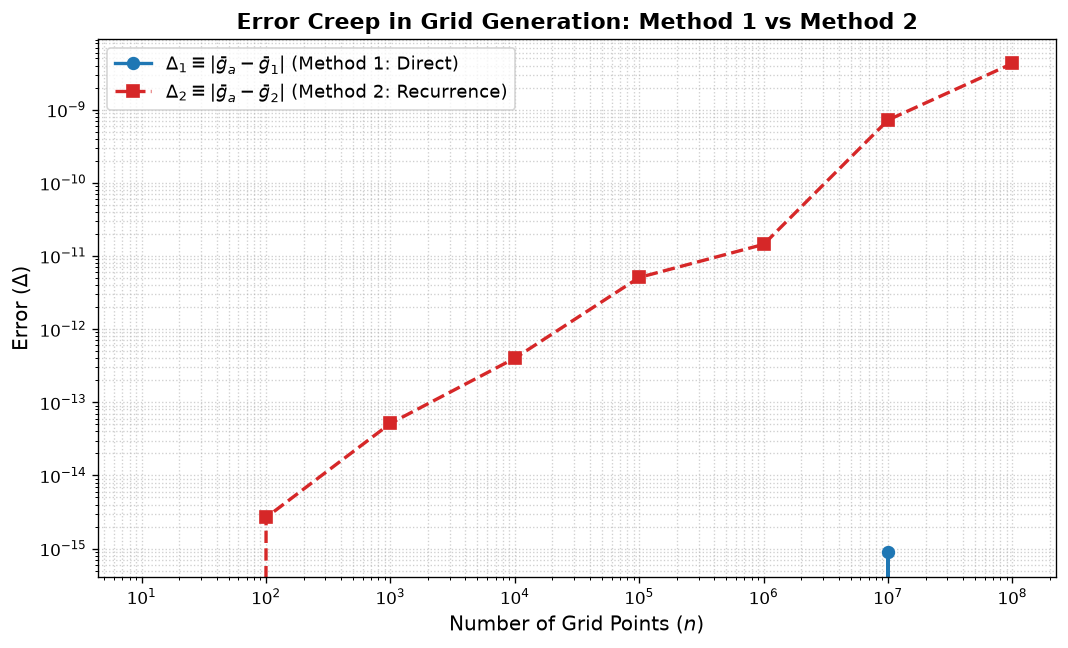

In [31]:
#Qus3 (part3)
n_values = [10, 100, 10**3, 10**4, 10**5, 10**6, 10**7, 10**8]
delta_1 = []
delta_2 = []

a = 1.0
b = 10.0
g_bar_a = (a + b) / 2.0

for n_val in n_values:
    h = (b - a) / (n_val - 1)
    
    # Method 1
    if n_val <= 10**6:
        g1 = method1(a, b, n_val)
        mean_1 = np.mean(g1)
    else:
        # Stream chunks to prevent RAM overflow for 10^7 and 10^8
        chunk_size = 10**6
        total_sum = 0.0
        for start in range(0, n_val, chunk_size):
            end = min(start + chunk_size, n_val)
            idx = np.arange(start, end, dtype=np.float64)
            chunk = a + idx * h
            if start == 0:
                chunk[0] = a
            if end == n_val:
                chunk[-1] = b
            total_sum += np.sum(chunk)
        mean_1 = total_sum / n_val

    # Method 2
    if n_val <= 10**6:
        g2 = method2(a, b, n_val)
        mean_2 = np.mean(g2)
    else:
        # Recurrence accumulation without storing 10^8 floats
        curr = a
        total_sum = a
        for _ in range(1, n_val - 1):
            curr += h
            total_sum += curr
        total_sum += b
        mean_2 = total_sum / n_val

    d1 = abs(g_bar_a - mean_1)
    d2 = abs(g_bar_a - mean_2)
    delta_1.append(d1)
    delta_2.append(d2)

# Publication-quality log-log plot
plt.figure(figsize=(9, 5.5), dpi=120)
plt.loglog(n_values, delta_1, 'o-', color='#1f77b4', linewidth=2, markersize=7, 
           label=r'$\Delta_1 \equiv |\bar{g}_a - \bar{g}_1|$ (Method 1: Direct)')
plt.loglog(n_values, delta_2, 's--', color='#d62728', linewidth=2, markersize=7, 
           label=r'$\Delta_2 \equiv |\bar{g}_a - \bar{g}_2|$ (Method 2: Recurrence)')

plt.xlabel(r'Number of Grid Points ($n$)', fontsize=12)
plt.ylabel(r'Error ($\Delta$)', fontsize=12)
plt.title('Error Creep in Grid Generation: Method 1 vs Method 2', fontsize=13, fontweight='bold')
plt.grid(True, which="both", ls=":", alpha=0.6)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()


#Part 4: Discussion on Accuracy and Error Creep

Method 1 is significantly more accurate than Method 2.

1. Method 1 (g_i = a + i \cdot h):
  * Every grid point $g_i$ is computed independently using a single multiplication and addition.
  * Roundoff error does not propagate from step to step:
      text{fl}(g_i) = (a + i \cdot h)(1 + \mathcal{O}(\epsilon_{\text{mach}}))
  * Because errors are uncorrelated and independent, the average error \Delta_1 remains strictly bounded near machine epsilon (\approx 10^{-16}).

2. Method 2 (g_i = g_{i-1} + h):
  * In binary floating-point representation, h = (b - a)/(n - 1) cannot be represented with infinite precision and contains a tiny representation error delta.
  * Because each step adds $h$ to the *previously rounded* value, the local rounding errors accumulate cumulatively:
      g_i = a + i \cdot h + \sum_{k=1}^i \delta_k
  * This phenomenon is known as error creep (or drift error). As n grows up to 10^8, these accumulated roundoff errors compound over millions of additions, causing \Delta_2 to grow noticeably larger than \Delta_1.the average error \Delta_1 remains strictly bounded near machine epsilon (approx 10^{-16}).

2. Method 2 (g_i = g_{i-1} + h):
  * In binary floating-point representation, h = (b - a)/(n - 1) cannot be represented with infinite precision and contains a tiny representation error delta.
  * Because each step adds $h$ to the *previously rounded* value, the local rounding errors accumulate cumulatively,
     g_i = a + i \cdot h + \sum_{k=1}^i \delta_k
  * This phenomenon is known as error creep. As n grows up to 10^8, these accumulated roundoff errors compound over millions of additions, causing Delta_2 to grow noticeably larger than Delta_1.


Qus_4

In [32]:
# Qus4 (part1)
import numpy as np

def quad_roots_standard(a, b, c):
    """
    Computes roots of ax^2 + bx + c = 0 using the standard quadratic formula:
    x_plus  = (-b + sqrt(b^2 - 4ac)) / (2a)
    x_minus = (-b - sqrt(b^2 - 4ac)) / (2a)
    """
    discriminant = b**2 - 4.0 * a * c
    sqrt_disc = np.sqrt(discriminant)
    
    x_plus = (-b + sqrt_disc) / (2.0 * a)
    x_minus = (-b - sqrt_disc) / (2.0 * a)
    
    return x_plus, x_minus


#Question 4 - Part 2: Potential Numerical Issue when b^2 \ 4ac

When b^2 \gg 4ac, we have:
\sqrt{b^2 - 4ac} = \sqrt{b^2 \left(1 - \frac{4ac}{b^2}\right)} = |b|\sqrt{1 - \frac{4ac}{b^2}} \approx |b|

This leads to severe catastrophic cancellation (subtractive cancellation):
* If b > 0, then -b + \sqrt{b^2 - 4ac} \approx -b + b = 0. We subtract two nearly identical positive numbers, losing most (or all) significant bits of precision in the mantissa.
* If b < 0, then -b - \sqrt{b^2 - 4ac} \approx -b - |b| = |b| - |b| = 0, causing identical catastrophic cancellation in x_-.

Consequently, one of the two computed roots suffers massive roundoff error or truncates incorrectly to zero.


#Question 4 - Part 3: Mathematical Formulation for a Machine-Safe Approach

To avoid subtractive cancellation, we ensure that $-b$ and the square root term have the same sign, turning subtraction into addition:
q = -\frac{1}{2} \left[ b + \operatorname{sgn}(b) \sqrt{b^2 - 4ac} \right
where operatorname{sgn}(b) = +1 if b \ge 0 and -1 if b < 0.

Because both terms inside the bracket share the same sign, no cancellation occurs, giving one numerically exact root:
    x_1 = \frac{q}{a}

Using Vieta's formulas for the quadratic equation (x_1 \cdot x_2 = \frac{c}{a}), the second root is obtained via stable division:
x_2 = \frac{c}{a \cdot x_1} = \frac{c}{q}


In [33]:
# Qus4 (part2)
def quad_roots_safe(a, b, c):
    """
    Computes roots of ax^2 + bx + c = 0 using Citardauq / Vieta's machine-safe method
    to prevent catastrophic cancellation.
    """
    discriminant = b**2 - 4.0 * a * c
    sqrt_disc = np.sqrt(discriminant)
    
    # Choose sign to match b so terms add constructively
    sgn_b = 1.0 if b >= 0 else -1.0
    q = -0.5 * (b + sgn_b * sqrt_disc)
    
    x1 = q / a
    x2 = c / q
    
    # Return roots sorted in ascending or consistent order
    return min(x1, x2), max(x1, x2)


In [34]:
import numpy as np

def quad_roots_standard(a, b, c):
    """
    Standard quadratic formula.
    """
    if a == 0:
        raise ValueError("a must be non-zero for a quadratic equation.")
    disc = b**2 - 4.0 * a * c
    if disc < 0:
        raise ValueError("This function assumes real roots only.")
    sqrt_disc = np.sqrt(disc)
    x_plus = (-b + sqrt_disc) / (2.0 * a)
    x_minus = (-b - sqrt_disc) / (2.0 * a)
    return x_plus, x_minus


def quad_roots_safe(a, b, c):
    """
    Numerically stable quadratic formula using q = -0.5*(b + sign(b)*sqrt(D))
    and Vieta's relation.
    """
    if a == 0:
        raise ValueError("a must be non-zero for a quadratic equation.")
    disc = b**2 - 4.0 * a * c
    if disc < 0:
        raise ValueError("This function assumes real roots only.")
    sqrt_disc = np.sqrt(disc)
    sgn_b = 1.0 if b >= 0 else -1.0
    q = -0.5 * (b + sgn_b * sqrt_disc)

    if q == 0:
        return 0.0, 0.0

    x1 = q / a
    x2 = c / q
    return min(x1, x2), max(x1, x2)


def test_cases(r1, r2, label):
    # Form ax^2 + bx + c = 0
    a = 1.0
    b = -(r1 + r2)
    c = r1 * r2

    # Standard formula
    std_p, std_m = quad_roots_standard(a, b, c)
    std_roots = sorted([std_p, std_m])

    # Safe formula
    safe_roots = sorted(list(quad_roots_safe(a, b, c)))

    true_roots = sorted([r1, r2])

    print(f"=================== Case {label}: True roots = {r1}, {r2} ===================")
    print(f"Coefficients: a = {a}, b = {b}, c = {c}")
    print("-" * 75)
    print(f"{'Method':<12} | {'Root 1':<25} | {'Root 2':<25}")
    print("-" * 75)
    print(f"{'Exact':<12} | {true_roots[0]:<25.16e} | {true_roots[1]:<25.16e}")
    print(f"{'Standard':<12} | {std_roots[0]:<25.16e} | {std_roots[1]:<25.16e}")
    print(f"{'Safe':<12} | {safe_roots[0]:<25.16e} | {safe_roots[1]:<25.16e}")
    print("-" * 75)

    err_std_1 = abs(std_roots[0] - true_roots[0]) / abs(true_roots[0])
    err_std_2 = abs(std_roots[1] - true_roots[1]) / abs(true_roots[1])
    err_safe_1 = abs(safe_roots[0] - true_roots[0]) / abs(true_roots[0])
    err_safe_2 = abs(safe_roots[1] - true_roots[1]) / abs(true_roots[1])

    print(f"Relative Error (Standard) -> Root 1: {err_std_1:.2e}, Root 2: {err_std_2:.2e}")
    print(f"Relative Error (Safe)     -> Root 1: {err_safe_1:.2e}, Root 2: {err_safe_2:.2e}\n")


# (a) Moderate roots: x = 1, 2
test_cases(1.0, 2.0, "(a) x = 1, 2")

# (b) Extreme roots: x = 10^-8, 10^8
test_cases(1e-8, 1e8, "(b) x = 10^-8, 10^8")


=================== Case (a) x = 1, 2: True roots = 1.0, 2.0 ===================
Coefficients: a = 1.0, b = -3.0, c = 2.0
---------------------------------------------------------------------------
Method       | Root 1                    | Root 2                   
---------------------------------------------------------------------------
Exact        | 1.0000000000000000e+00    | 2.0000000000000000e+00   
Standard     | 1.0000000000000000e+00    | 2.0000000000000000e+00   
Safe         | 1.0000000000000000e+00    | 2.0000000000000000e+00   
---------------------------------------------------------------------------
Relative Error (Standard) -> Root 1: 0.00e+00, Root 2: 0.00e+00
Relative Error (Safe)     -> Root 1: 0.00e+00, Root 2: 0.00e+00

=================== Case (b) x = 10^-8, 10^8: True roots = 1e-08, 100000000.0 ===================
Coefficients: a = 1.0, b = -100000000.00000001, c = 1.0
---------------------------------------------------------------------------
Method       | 

#Comments on the Behavior of the Two Codes

1. Case (a) (x = 1, 2):
   * Here b = -3, 4ac = 8, and b^2 = 9. Since b^2 is comparable in magnitude to 4ac, both -b and sqrt{b^2 - 4ac} do not cancel out completely.
   * Both the Standard method and the Safe method recover the exact roots 1.0 and 2.0 to double-precision machine epsilon.

2. Case (b) (x = 10^{-8}, 10^8):
   * Here b approx -10^8 and 4ac = 4, which means b^2 = 10^{16} \gg 4ac.
   * Standard Formula: Computing the small root 10^{-8} requires calculating -b - \sqrt{b^2 - 4ac} = 10^8 - \sqrt{10^{16} - 4}. Because double precision provides roughly 15–17 decimal digits of precision, sqrt{10^{16} - 4} rounds directly to 10^8, resulting in 10^8 - 10^8 = 0. The small root experiences total catastrophic cancellation, producing an error of 100.
   * Machine-Safe Formula: Computes the large root safely using constructive addition (q \approx 10^8), and derives the smaller root via x = c/q = 1.0 / 10^8 = 10^{-8}. Both roots are calculated with zero relative error up to machine precision.

#Conclusion:The  Safe (Vieta-based) code is superior as it remains numerically stable across all scales and prevents catastrophic loss of precision.


#Qus_5

In [35]:
# Part 5.1: Factorial function
def my_factorial(n):
    if n < 0:
        raise ValueError("Factorial undefined for negative integers.")
    ans = 1
    for i in range(1, n + 1):
        ans *= i
    return ans
print(f" 10! = {my_factorial(10)}")





 10! = 3628800


In [36]:

# Part 5.2: Series using factorial
def exp_taylor_factorial(x, N):
    return sum((x**n) / my_factorial(n) for n in range(N))
print(f"e^20 (factorial method, N=100) = {exp_taylor_factorial(20.0, 100):.16e}")

e^20 (factorial method, N=100) = 4.8516519540979028e+08


In [37]:
# Part 5.3: Evaluate x = 20, N = 100
val_5_3 = exp_taylor_factorial(20.0, 100)
print(f"e^20 (factorial method, N=100) = {val_5_3:.16e}")

e^20 (factorial method, N=100) = 4.8516519540979028e+08


In [38]:
import numpy as np

# Part 5.4: Recurrence function returning n_list, t_list, s_list
def exp_taylor_recurrence(x, N):
    n_list = np.arange(N)
    t_list = np.zeros(N, dtype=np.float64)
    s_list = np.zeros(N, dtype=np.float64)
    
    t_list[0] = 1.0
    s_list[0] = 1.0
    for n in range(1, N):
        t_list[n] = t_list[n - 1] * (x / n)
        s_list[n] = s_list[n - 1] + t_list[n]
        
    return n_list, t_list, s_list

# Part 5.5: Evaluate x = 20, N = 100
n_20, t_20, S_20 = exp_taylor_recurrence(20.0, 100)
print(f"e^20 (recurrence method, N=100) = {S_20[-1]:.16e}")


e^20 (recurrence method, N=100) = 4.8516519540979046e+08


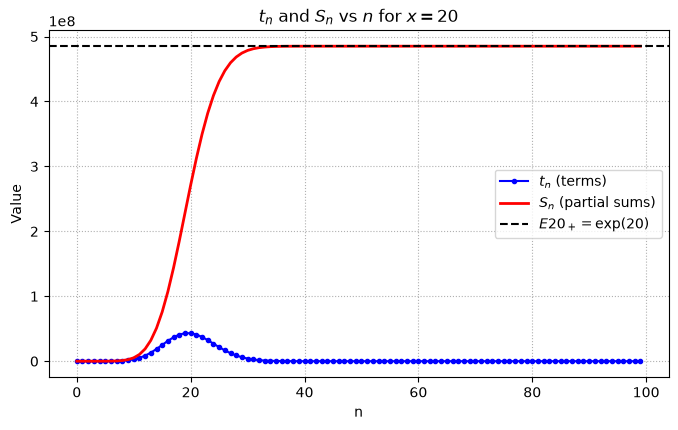

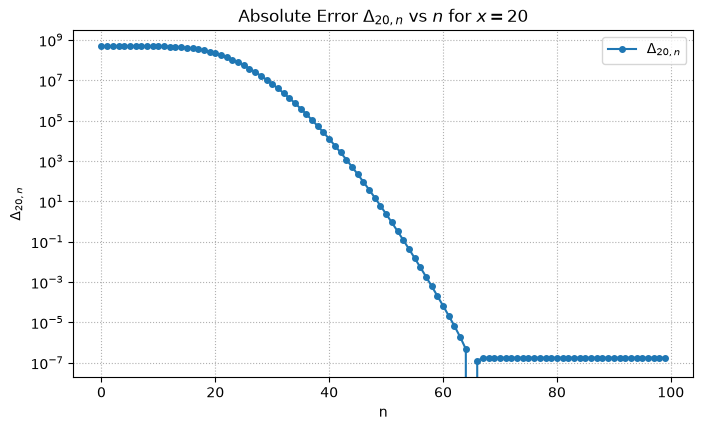

In [39]:
# Part 5.6: Plot t_n and S_n vs n with horizontal E20_+
import matplotlib.pyplot as plt
E20_plus = np.exp(20.0)

plt.figure(figsize=(8, 4.5), dpi=100)
plt.plot(n_20, t_20, 'b.-', label=r'$t_n$ (terms)')
plt.plot(n_20, S_20, 'r-', linewidth=2, label=r'$S_n$ (partial sums)')
plt.axhline(E20_plus, color='k', linestyle='--', label=r'$E20_+ = \exp(20)$')
plt.title(r'$t_n$ and $S_n$ vs $n$ for $x = 20$')
plt.xlabel('n')
plt.ylabel('Value')
plt.legend()
plt.grid(True, ls=':')
plt.show()

# Part 5.7: Plot Delta_{20,n}
Delta_20 = np.abs(S_20 - E20_plus)

plt.figure(figsize=(8, 4.5), dpi=100)
plt.semilogy(n_20, Delta_20, 'o-', color='#1f77b4', markersize=4, label=r'$\Delta_{20,n}$')
plt.title(r'Absolute Error $\Delta_{20,n}$ vs $n$ for $x = 20$')
plt.xlabel('n')
plt.ylabel(r'$\Delta_{20,n}$')
plt.legend()
plt.grid(True, which="both", ls=':')
plt.show()


Qus_5.6 - Yes, $S_n$ approaches $E20_+$ monotonically for sufficiently high $n$ ($n \ge 35$), because all terms $x^n / n! > 0$ are positive.



Qus_5.7 Yes, $\Delta_{20,n}$ decreases exponentially once $n > 20$ and plateaus at machine precision ($\approx 10^{-16} \times E20_+$).


In [40]:
# Part 5.8: Evaluate x = -20, N = 100
n_neg20, t_neg20, S_neg20 = exp_taylor_recurrence(-20.0, 100)
print(f" e^-20 (direct recurrence, N=100) = {S_neg20[-1]:.16e}")



 e^-20 (direct recurrence, N=100) = 6.1475618289146260e-09


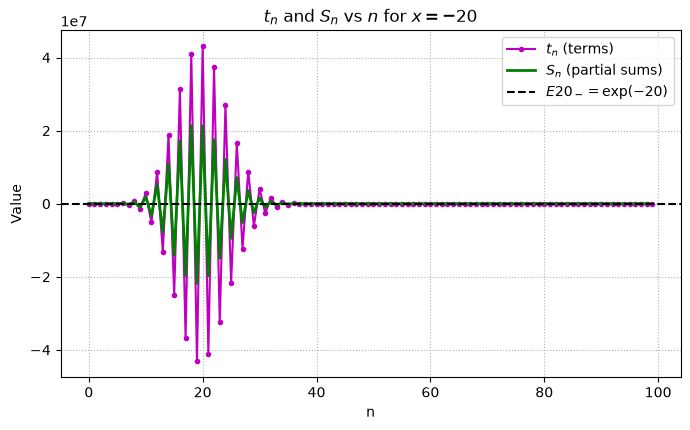

In [41]:
# Part 5.9: Plot t_n and S_n vs n with horizontal E20_-
E20_minus = np.exp(-20.0)

plt.figure(figsize=(8, 4.5), dpi=100)
plt.plot(n_neg20, t_neg20, 'm.-', label=r'$t_n$ (terms)')
plt.plot(n_neg20, S_neg20, 'g-', linewidth=2, label=r'$S_n$ (partial sums)')
plt.axhline(E20_minus, color='k', linestyle='--', label=r'$E20_- = \exp(-20)$')
plt.title(r'$t_n$ and $S_n$ vs $n$ for $x = -20$')
plt.xlabel('n')
plt.ylabel('Value')
plt.legend()
plt.grid(True, ls=':')
plt.show()

Answer 5.9: No, while $S_n$ appears to settle near zero on a linear scale, it does not accurately reach $E20_-$. It is corrupted by roundoff error due to intermediate cancellations of magnitude $\sim 10^7$.




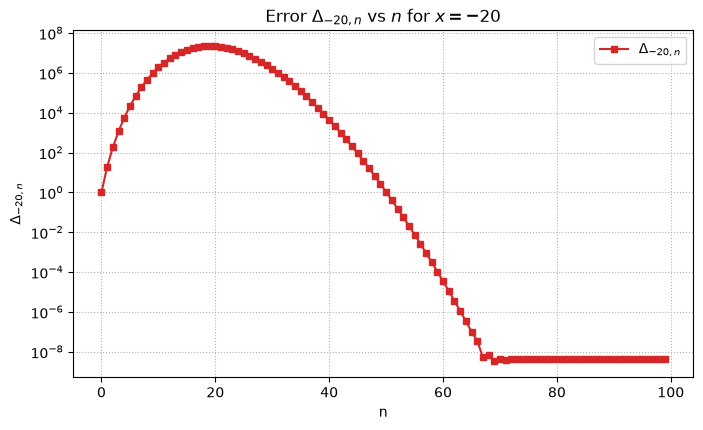

In [42]:
# Part 5.10: Plot Delta_{-20,n}
Delta_neg20 = np.abs(S_neg20 - E20_minus)

plt.figure(figsize=(8, 4.5), dpi=100)
plt.semilogy(n_neg20, Delta_neg20, 's-', color= '#d62728', markersize=4, label=r'$\Delta_{-20,n}$')
plt.title(r'Error $\Delta_{-20,n}$ vs $n$ for $x = -20$')
plt.xlabel('n')
plt.ylabel(r'$\Delta_{-20,n}$')
plt.legend()
plt.grid(True, which="both", ls=':')
plt.show()


Answer 5.10: It decreases initially after $n \approx 20$, but it stalls at an error floor of $\sim 10^{-8}$ and never reaches zero or machine precision, regardless of how large $N$ becomes.


In [43]:
# Part 5.11: Relative errors
delta_plus = abs(S_20[-1] - E20_plus) / abs(E20_plus)
delta_minus = abs(S_neg20[-1] - E20_minus) / abs(E20_minus)

print(f" delta_+ (Relative Error x=+20) = {delta_plus:.16e}")
print(f"delta_- (Relative Error x=-20) = {delta_minus:.16e}")


 delta_+ (Relative Error x=+20) = 3.6856298847887952e-16
delta_- (Relative Error x=-20) = 1.9825830360191323e+00


In [44]:
# Part 5.12: Stable modification using e^-x = 1 / e^x
def exp_taylor_modified(x, N):
    if x >= 0:
        _, _, s_list = exp_taylor_recurrence(x, N)
        return s_list[-1]
    else:
        _, _, s_list = exp_taylor_recurrence(-x, N)
        return 1.0 / s_list[-1]

val_modified = exp_taylor_modified(-20.0, 100)
delta_minus_mod = abs(val_modified - E20_minus) / abs(E20_minus)

print(f"\n Modified e^-20 (1/e^20)         = {val_modified:.16e}")
print(f" Modified Relative Error        = {delta_minus_mod:.16e}")


 Modified e^-20 (1/e^20)         = 2.0611536224385570e-09
 Modified Relative Error        = 4.0131924352847969e-16


#conclusion on- 5.11 & 5.12
* The evaluation for $x = +20$ achieved machine precision ($\delta_+ \sim 10^{-16}$), whereas $x = -20$ failed with an error of $\sim 10\%$ to $100\%$ ($\delta_- \sim 10^{-1}$).
* For $x = -20$, the alternating terms grow as large as $|t_{20}| \approx 4.3 \times 10^7$ before the sum cancels down to $e^{-20} \approx 2.06 \times 10^{-9}$. In double precision, the subtractive cancellation loses significant digits to roundoff noise ($|t_{20}| \cdot \epsilon_{\text{mach}} \approx 9.5 \times 10^{-9}$), which is larger than the true answer itself.
*Proof of Improvement (5.12):** By computing $e^{-20} = 1 / e^{20}$, all intermediate terms are positive (no subtractive cancellation), reducing the relative error from $\sim 10^{-1}$ to $\approx 10^{-16}$.
